In [1]:
# import nbformat
# from google.colab import files

# nb_path = "/content/drive/MyDrive/Colab Notebooks/MS4_DETR.ipynb"   # change to your notebook name

# nb = nbformat.read(nb_path, as_version=4)

# # 🔥 Remove widget metadata ONLY
# if "widgets" in nb["metadata"]:
#     del nb["metadata"]["widgets"]

# nbformat.write(nb, nb_path)

# print("✅ Cleaned notebook (outputs preserved)")

# files.download(nb_path)

# DEtection TRansformer (DETR)

Pros:

1. No region proposal tuning
2. Sigle stage pipeline
3. Single loss function

Cons:

1.   Data hungry
2.   Strugles with small objects
3.   Too big to fit in mobile


Requires:

> The follicle data be loaded into drive or directly into colab runtime environment.
> The fine-tuned model is in my drive. I can share if needed (to avoid re-trianing).

Key Param:

The number of decoder queries is set to 100. Given that the median number of objects per image is 12, this value can be reduced to help minimize overlapping predictions.



In [2]:
import os
import xml.etree.ElementTree as ET
from dataclasses import dataclass
from typing import List, Dict, Any

import torch
from torch.utils.data import Dataset
from PIL import Image, ImageDraw, ImageFont

from transformers import (
    DetrImageProcessor,
    DetrForObjectDetection,
    TrainingArguments,
    Trainer
)

import pandas as pd
import matplotlib.pyplot as plt
import json
from transformers import DetrConfig

import cv2
import numpy as np
from torch.utils.data import Dataset
import albumentations as A
from typing import List, Optional


import torch.nn.functional as F

from scipy.optimize import linear_sum_assignment

from torchvision.ops import (
    box_convert,
    generalized_box_iou
)

import torch
from torch.utils.data import DataLoader
from transformers import Trainer
from collections import Counter
from torchvision.ops import box_convert

In [3]:
# Detect whether we're running on Colab or locally so the Drive mount,
# data copy, and checkpoint paths can branch accordingly.
try:
    import google.colab  # noqa: F401
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    DATA_ROOT = "/content/data"
    CHECKPOINT_ROOT = "/content/drive/MyDrive"
else:
    # Walk up from cwd until we find the .git directory (the repo root).
    _p = os.path.abspath('.')
    while _p != '/' and not os.path.isdir(os.path.join(_p, '.git')):
        _p = os.path.dirname(_p)
    if not os.path.isdir(os.path.join(_p, '.git')):
        raise RuntimeError(
            f"Could not find repo root (no .git found walking up from {os.path.abspath('.')}). "
            "Launch the notebook from inside the hair-follicle-density-estimation-209b repo."
        )
    REPO_ROOT = _p
    DATA_ROOT = os.path.join(REPO_ROOT, "data")
    CHECKPOINT_ROOT = os.path.join(REPO_ROOT, "MS4", "checkpoints")
    os.makedirs(CHECKPOINT_ROOT, exist_ok=True)

print(f"IS_COLAB={IS_COLAB}")
print(f"DATA_ROOT={DATA_ROOT}")
print(f"CHECKPOINT_ROOT={CHECKPOINT_ROOT}")


IS_COLAB=False
DATA_ROOT=/Users/Roshan/Library/Mobile Documents/com~apple~CloudDocs/Documents/MIT MFin/Semesters/Spring/CS 1090B/hair-follicle-density-estimation-209b/data
CHECKPOINT_ROOT=/Users/Roshan/Library/Mobile Documents/com~apple~CloudDocs/Documents/MIT MFin/Semesters/Spring/CS 1090B/hair-follicle-density-estimation-209b/MS4/checkpoints


In [4]:
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')


In [5]:
if IS_COLAB:
    os.system("cp -r /content/drive/MyDrive/data /content/")


# CONFIG

In [6]:
# ============================================================
# CONFIG: setting params
# ============================================================

@dataclass
class Config:
    # paths
    image_dir: str = "/content/data/Images"
    annot_dir: str = "/content/data/Annotations"
    output_dir: str = "./detr_voc_finetuned"

    # model
    pretrained_model_name: str = "facebook/detr-resnet-50"
    image_size: int = 800
    num_queries: int = 100

    # classes
    class_names: Optional[List[str]] = None

    # training
    per_device_train_batch_size: int = 2
    per_device_eval_batch_size: int = 2
    gradient_accumulation_steps: int = 4 #effective batch size=8
    num_train_epochs: int = 30

    # optimizer
    learning_rate: float = 1e-4
    lr_backbone: float = 1e-5 # we don't want Resnet change too much
    weight_decay: float = 1e-4
    warmup_steps: int = 500
    lr_scheduler_type: str = "cosine"

    # dataloader/checkpoint
    num_workers: int = 0 # macOS DataLoader workers segfault under fork; Colab overrides below
    save_total_limit: int = 2 # keep only 2

    # imbalance handling: custom flags, not built into DETR
    use_weighted_sampler: bool = True
    use_class_weighted_loss: bool = True
    class_weight_alpha: float = 1.0

    # augmentation
    use_augmentation: bool = True

    # evaluation
    iou_threshold: float = 0.5
    score_threshold: float = 0.05

    def __post_init__(self):
        if self.class_names is None:
            self.class_names = [
                "premium",
                "single",
                "undersize",
                "abnormal",
            ]

        self.label2id = {
            name: i for i, name in enumerate(self.class_names)
        }

        self.id2label = {
            i: name for i, name in enumerate(self.class_names)
        }

        self.num_labels = len(self.class_names)


cfg = Config()

# Override the dataclass defaults with platform-aware paths.
cfg.image_dir = os.path.join(DATA_ROOT, "Images")
cfg.annot_dir = os.path.join(DATA_ROOT, "Annotations")
cfg.num_workers = 2 if IS_COLAB else 0

# Pascal VOC class ids must start from 0
id2label = {i: name for i, name in enumerate(cfg.class_names)}
label2id = {name: i for i, name in id2label.items()}


# training and validation split

In [7]:
# load training and validation file names
SPLIT_DIR = os.path.join(DATA_ROOT, "ImageSets", "Main")

with open(os.path.join(SPLIT_DIR, "train.txt")) as f:
    train_files = [fnm[:-1] for fnm in f.readlines()]

with open(os.path.join(SPLIT_DIR, "val.txt")) as f:
    val_files = [fnm[:-1] for fnm in f.readlines()]


# XML Parser

In [8]:
def scale_box_xyxy(box, scale, img_w, img_h):
    x1, y1, x2, y2 = box

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = (x2 - x1) * scale
    bh = (y2 - y1) * scale

    new_box = [
        cx - bw / 2,
        cy - bh / 2,
        cx + bw / 2,
        cy + bh / 2,
    ]

    return clip_box_xyxy(new_box, img_w, img_h)


def downscale_box_xyxy(box, scale):
    x1, y1, x2, y2 = box

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = (x2 - x1) / scale
    bh = (y2 - y1) / scale

    return [
        cx - bw / 2,
        cy - bh / 2,
        cx + bw / 2,
        cy + bh / 2,
    ]


def downscale_boxes_xyxy(boxes, scale):
    boxes = boxes.clone()

    cx = (boxes[:, 0] + boxes[:, 2]) / 2
    cy = (boxes[:, 1] + boxes[:, 3]) / 2
    bw = (boxes[:, 2] - boxes[:, 0]) / scale
    bh = (boxes[:, 3] - boxes[:, 1]) / scale

    boxes[:, 0] = cx - bw / 2
    boxes[:, 1] = cy - bh / 2
    boxes[:, 2] = cx + bw / 2
    boxes[:, 3] = cy + bh / 2

    return boxes

In [9]:

# ============================================================
# XML Parser and bbox fixer
# ============================================================

def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = box
    x1 = max(0.0, min(float(x1), width - 1))
    y1 = max(0.0, min(float(y1), height - 1))
    x2 = max(0.0, min(float(x2), width - 1))
    y2 = max(0.0, min(float(y2), height - 1))
    return [x1, y1, x2, y2]

def is_valid_xyxy(box):
    x1, y1, x2, y2 = box
    return (x2 > x1) and (y2 > y1)
#coco style bounding box
def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return [x1, y1, x2 - x1, y2 - y1]

def parse_voc_xml(xml_path: str, label2id: Dict[str, int]) -> Dict[str, Any]:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    width = int(size.findtext("width"))
    height = int(size.findtext("height"))

    objects = []
    for obj in root.findall("object"):
        name = obj.findtext("name")
        if name is None:
            name = obj.findtext("class")
        if name is None:
            continue

        name = name.strip().lower()
        if name not in label2id:
            continue

        bndbox = obj.find("bndbox")
        if bndbox is None:
            continue

        xmin = float(bndbox.findtext("xmin"))
        ymin = float(bndbox.findtext("ymin"))
        xmax = float(bndbox.findtext("xmax"))
        ymax = float(bndbox.findtext("ymax"))

        # Repair reversed coordinates
        x1, x2 = sorted([xmin, xmax])
        y1, y2 = sorted([ymin, ymax])

        # Clip to XML-declared image size
        x1 = max(0.0, min(x1, width - 1))
        y1 = max(0.0, min(y1, height - 1))
        x2 = max(0.0, min(x2, width - 1))
        y2 = max(0.0, min(y2, height - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        difficult = obj.findtext("difficult")
        difficult = int(difficult) if difficult is not None else 0

        objects.append({
            "name": name,
            "class_id": label2id[name],
            "bbox_xyxy": [x1, y1, x2, y2],
            "difficult": difficult,#how difficult is the object to detect
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects,
    }



# Data Augmentation

In [10]:
#Augmentation
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),

        A.Rotate(
            limit=5,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.4
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.4
        ),

        A.CLAHE(
            clip_limit=2.0,
            tile_grid_size=(8, 8),
            p=0.3
        ),

        A.Sharpen(
            alpha=(0.1, 0.25),
            lightness=(0.8, 1.2),
            p=0.25
        ),

        A.GaussNoise(p=0.15),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",          # [xmin, ymin, xmax, ymax]
        label_fields=["class_labels"],
        min_visibility=0.3
    )
)
val_transform = None


# Dataset Class

In [11]:
class PascalVOCDataset(Dataset):
    def __init__(
        self,
        image_dir,
        annot_dir,
        processor,
        label2id,
        split,
        transform=None,
        box_scale=1.0,
    ):
        self.image_dir = image_dir
        self.annot_dir = annot_dir
        self.processor = processor
        self.label2id = label2id
        self.split = set(split)
        self.transform = transform
        self.box_scale = box_scale

        self.xml_files = sorted([
            f for f in os.listdir(annot_dir)
            if f.endswith(".xml") and os.path.splitext(f)[0] in self.split
        ])

    def __len__(self):
        return len(self.xml_files)

    def __getitem__(self, idx):
        xml_file = self.xml_files[idx]
        xml_path = os.path.join(self.annot_dir, xml_file)

        parsed = parse_voc_xml(xml_path, self.label2id)

        image_filename = parsed["filename"]
        image_path = os.path.join(self.image_dir, image_filename)

        if not os.path.exists(image_path):
            stem = os.path.splitext(xml_file)[0]
            found = False
            for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
                alt_path = os.path.join(self.image_dir, stem + ext)
                if os.path.exists(alt_path):
                    image_path = alt_path
                    found = True
                    break
            if not found:
                raise FileNotFoundError(f"Image not found for XML: {xml_path}")

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        boxes_xyxy = []
        class_labels = []

        for obj in parsed["objects"]:
            box_xyxy = clip_box_xyxy(obj["bbox_xyxy"], width, height)

            if not is_valid_xyxy(box_xyxy):
                continue

            # scale GT box BEFORE augmentation and processor
            if self.box_scale != 1.0:
                box_xyxy = scale_box_xyxy(
                    box_xyxy,
                    scale=self.box_scale,
                    img_w=width,
                    img_h=height
                )

            if not is_valid_xyxy(box_xyxy):
                continue

            x_min, y_min, x_max, y_max = box_xyxy

            if x_max <= x_min or y_max <= y_min:
                continue

            boxes_xyxy.append([
                float(x_min),
                float(y_min),
                float(x_max),
                float(y_max)
            ])

            class_labels.append(int(obj["class_id"]))

        image_np = np.array(image)

        if self.transform is not None and len(boxes_xyxy) > 0:
            transformed = self.transform(
                image=image_np,
                bboxes=boxes_xyxy,
                class_labels=class_labels
            )

            image_np = transformed["image"]
            boxes_xyxy = list(transformed["bboxes"])
            class_labels = list(transformed["class_labels"])

        height, width = image_np.shape[:2]

        annotations = []
        ann_id = 0

        for box_xyxy, class_id in zip(boxes_xyxy, class_labels):
            box_xyxy = clip_box_xyxy(box_xyxy, width, height)

            if not is_valid_xyxy(box_xyxy):
                continue

            x, y, w, h = xyxy_to_xywh(box_xyxy)

            if w <= 1 or h <= 1:
                continue

            annotations.append({
                "id": ann_id,
                "image_id": idx,
                "category_id": int(class_id),
                "bbox": [float(x), float(y), float(w), float(h)],
                "area": float(w * h),
                "iscrowd": 0,
            })

            ann_id += 1

        target = {
            "image_id": idx,
            "annotations": annotations,
        }

        encoding = self.processor(
            images=image_np,
            annotations=target,
            return_tensors="pt",
        )

        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "labels": encoding["labels"][0],
        }

In [12]:

processor = DetrImageProcessor.from_pretrained(
    cfg.pretrained_model_name,
    size={"shortest_edge": cfg.image_size, "longest_edge": 1333},
)

# Make data ready to be consumed by loader. transformers >=5.6 dropped
# processor.pad(list_of_images, return_tensors=...), so pad manually.
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    labels = [item["labels"] for item in batch]

    max_h = max(pv.shape[-2] for pv in pixel_values)
    max_w = max(pv.shape[-1] for pv in pixel_values)

    padded = []
    masks = []
    for pv in pixel_values:
        c, h, w = pv.shape
        out = torch.zeros((c, max_h, max_w), dtype=pv.dtype)
        out[:, :h, :w] = pv
        padded.append(out)
        mask = torch.zeros((max_h, max_w), dtype=torch.long)
        mask[:h, :w] = 1
        masks.append(mask)

    return {
        "pixel_values": torch.stack(padded),
        "pixel_mask": torch.stack(masks),
        "labels": labels,
    }

# Create Dataset

In [13]:
# ============================================================
# Create Dataset
# ============================================================

train_dataset = PascalVOCDataset(
    image_dir=cfg.image_dir,
    annot_dir=cfg.annot_dir,
    processor=processor,
    label2id=label2id,
    split=train_files,
    transform=train_transform,
    box_scale=1.2,
)

# val_dataset uses raw GT boxes so DETR's mAP is comparable to YOLO, which also
# evaluates on raw boxes. Training keeps the 1.2x context expansion.
val_dataset = PascalVOCDataset(
    image_dir=cfg.image_dir,
    annot_dir=cfg.annot_dir,
    processor=processor,
    label2id=label2id,
    split=val_files,
    transform=None,
    box_scale=1.0,
)


# balancing classes

In [14]:
import torch
import torch.nn.functional as F
from collections import Counter
from scipy.optimize import linear_sum_assignment
from torchvision.ops import box_convert, generalized_box_iou

# class counts
class_counts = Counter({
    0: 8063,  # premium
    1: 2815,  # single
    2: 917,   # undersize
    3: 422    # abnormal
})

# FIX: torch.tensor needs a list, not a dict
class_weights = torch.tensor(
    [1.0 / class_counts[i] for i in sorted(class_counts.keys())],
    dtype=torch.float
)

# normalize for stable loss scale
class_weights = class_weights / class_weights.mean()

print(class_weights)

tensor([0.1259, 0.3607, 1.1073, 2.4061])


In [15]:
def weighted_matched_class_loss(outputs, labels, class_weights, device):
    logits = outputs.logits          # [B, num_queries, num_classes + 1]
    pred_boxes = outputs.pred_boxes  # [B, num_queries, 4], normalized cxcywh

    batch_losses = []

    for b, target in enumerate(labels):
        tgt_labels = target["class_labels"].to(device)
        tgt_boxes = target["boxes"].to(device)

        if len(tgt_labels) == 0:
            continue

        out_prob = logits[b].softmax(-1)
        out_prob_obj = out_prob[:, :-1]  # remove no-object class

        out_bbox = pred_boxes[b]

        # matching costs
        cost_class = -out_prob_obj[:, tgt_labels]
        cost_bbox = torch.cdist(out_bbox, tgt_boxes, p=1)

        out_bbox_xyxy = box_convert(
            out_bbox,
            in_fmt="cxcywh",
            out_fmt="xyxy"
        )

        tgt_bbox_xyxy = box_convert(
            tgt_boxes,
            in_fmt="cxcywh",
            out_fmt="xyxy"
        )

        cost_giou = -generalized_box_iou(
            out_bbox_xyxy,
            tgt_bbox_xyxy
        )

        C = 1.0 * cost_class + 5.0 * cost_bbox + 2.0 * cost_giou
        C = C.detach().cpu().numpy()

        pred_indices, tgt_indices = linear_sum_assignment(C)

        pred_indices = torch.as_tensor(pred_indices, dtype=torch.long, device=device)
        tgt_indices = torch.as_tensor(tgt_indices, dtype=torch.long, device=device)

        matched_logits = logits[b, pred_indices, :-1]
        matched_labels = tgt_labels[tgt_indices]

        loss = F.cross_entropy(
            matched_logits,
            matched_labels,
            weight=class_weights.to(matched_logits.device)
        )

        batch_losses.append(loss)

    if len(batch_losses) == 0:
        return torch.tensor(0.0, device=device)

    return torch.stack(batch_losses).mean()

In [16]:
from torch.utils.data import WeightedRandomSampler


class ClassWeightedDetrTrainer(Trainer):
    def __init__(
        self, *args,
        class_weights=None, alpha_cls=1.0,
        sample_weights=None,                # per-image weights for WeightedRandomSampler
        lr_backbone=None, lr_head=None,     # differential LR: backbone vs head
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.alpha_cls = alpha_cls
        self.sample_weights = sample_weights
        self.lr_backbone = lr_backbone
        self.lr_head = lr_head

    def _get_train_sampler(self, *args, **kwargs):
        # Oversample rare-class images when per-image weights are provided.
        if self.sample_weights is None:
            return super()._get_train_sampler(*args, **kwargs)
        return WeightedRandomSampler(
            weights=self.sample_weights,
            num_samples=len(self.sample_weights),
            replacement=True,
        )

    def create_optimizer(self):
        # Two LR groups: ResNet backbone at lr_backbone, detection head at lr_head.
        # TrainingArguments only takes a single learning_rate, so without this
        # override both groups would train at the same rate.
        if self.optimizer is None and self.lr_head is not None and self.lr_backbone is not None:
            backbone_params = list(self.model.model.backbone.parameters())
            backbone_ids = {id(p) for p in backbone_params}
            head_params = [
                p for p in self.model.parameters()
                if p.requires_grad and id(p) not in backbone_ids
            ]
            self.optimizer = torch.optim.AdamW(
                [
                    {"params": backbone_params, "lr": self.lr_backbone},
                    {"params": head_params,     "lr": self.lr_head},
                ],
                weight_decay=self.args.weight_decay,
            )
        return super().create_optimizer()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        labels_on_device = [
            {k: v.to(model.device) for k, v in t.items()}
            for t in labels
        ]

        outputs = model(
            pixel_values=inputs["pixel_values"],
            pixel_mask=inputs.get("pixel_mask", None),
            labels=labels_on_device
        )

        detr_loss = outputs.loss

        extra_cls_loss = weighted_matched_class_loss(
            outputs=outputs,
            labels=labels_on_device,
            class_weights=self.class_weights,
            device=model.device
        )

        loss = detr_loss + self.alpha_cls * extra_cls_loss

        return (loss, outputs) if return_outputs else loss


In [17]:


# ============================================================
# TRAINING ARGS
# ============================================================

training_args = TrainingArguments(
    output_dir=cfg.output_dir,
    per_device_train_batch_size=cfg.per_device_train_batch_size,
    per_device_eval_batch_size=cfg.per_device_eval_batch_size,
    num_train_epochs= cfg.num_train_epochs,

    learning_rate=1e-5,
    weight_decay=cfg.weight_decay,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    save_total_limit=cfg.save_total_limit,
    remove_unused_columns=False,
    dataloader_num_workers=cfg.num_workers,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,#minimize loss

    fp16=False,   #caused OOM
    max_grad_norm=1.0,
    warmup_steps=500,# learning rate increases over 500 steps
  disable_tqdm=False
)


Model Training:

Fine tune entire parameters: It is suggested to tune both Resnet and Transformer together for co-adaptation.


In [18]:
# Fine tune a model or load from checkpoint if exists.
from transformers.utils import logging
logging.set_verbosity_error()

# Save under aug4 so the prior aug3 checkpoint on Drive is preserved as a baseline.
# Local checkpoints land under MS4/checkpoints/.
if IS_COLAB:
    save_path = os.path.join(CHECKPOINT_ROOT, "detr_follicle_model_aug4")
    hist_path = os.path.join(CHECKPOINT_ROOT, "detr_follicle_model", "training_log_history_aug4.json")
else:
    save_path = os.path.join(CHECKPOINT_ROOT, "detr_follicle_model_aug4")
    hist_path = os.path.join(CHECKPOINT_ROOT, "training_log_history_aug4.json")

os.makedirs(save_path, exist_ok=True)
os.makedirs(os.path.dirname(hist_path), exist_ok=True)

# Config overrides applied unconditionally so they take effect on every fresh train.
config = DetrConfig.from_pretrained(cfg.pretrained_model_name)
config.num_queries = 50              # reduces over-prediction
config.num_labels = len(cfg.class_names)
config.id2label = id2label
config.label2id = label2id
config.bbox_loss_coefficient = 8   # tighten bbox
config.giou_loss_coefficient = 4

logs = ''
if os.path.exists(os.path.join(save_path, "config.json")):
    print(f"Loading existing model from {save_path}...")
    model = DetrForObjectDetection.from_pretrained(save_path)
    processor = DetrImageProcessor.from_pretrained(save_path)
    if os.path.exists(hist_path):
        with open(hist_path, "r") as f:
            logs = json.load(f)
else:
    print("No saved model found. Training new model...")
    model = DetrForObjectDetection.from_pretrained(
        cfg.pretrained_model_name,
        config=config,
        ignore_mismatched_sizes=True,
    )

    # Conservative recipe. A prior run stacked three rare-class interventions
    # (WeightedRandomSampler + alpha_cls=0.5 + head LR 10x backbone) and the
    # model collapsed to a single-class predictor. This config disables those
    # three and falls back to the flat 1e-5 LR from TrainingArguments,
    # matching Yosef's aug3 recipe. Keeping num_queries=50 and val
    # box_scale=1.0 since those are independent of the imbalance question.
    trainer = ClassWeightedDetrTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=collate_fn,
        processing_class=processor,
        class_weights=class_weights,
        alpha_cls=0.0,
        sample_weights=None,
        lr_head=None,
        lr_backbone=None,
    )

    trainer.train()

    # ---- save ----
    logs = trainer.state.log_history
    trainer.save_model(save_path)
    processor.save_pretrained(save_path)

    # hist_path is absolute, so write to it directly. The earlier code used
    # os.path.join(save_path, hist_path) which silently dropped save_path.
    with open(hist_path, "w") as f:
        json.dump(logs, f, indent=2)

    print(f"Model saved to {save_path}")


No saved model found. Training new model...


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

/Users/Roshan/Library/Mobile Documents/com~apple~CloudDocs/Documents/MIT MFin/Semesters/Spring/CS 1090B/hw3/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,8.857716,14.272051
2,8.505159,13.616425
3,8.076748,13.532237
4,8.315934,13.167154
5,7.763435,13.147268
6,7.986913,13.945481
7,7.800705,13.044150
8,8.101033,13.119170
9,8.090059,13.150054
10,7.583135,12.759273


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/Roshan/Library/Mobile Documents/com~apple~CloudDocs/Documents/MIT MFin/Semesters/Spring/CS 1090B/hw3/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /Users/Roshan/Library/Mobile Documents/com~apple~CloudDocs/Documents/MIT MFin/Semesters/Spring/CS 1090B/hair-follicle-density-estimation-209b/MS4/checkpoints/detr_follicle_model_aug4


In [19]:
print(train_dataset.box_scale)
print(val_dataset.box_scale)

1.2
1.0


# Model Summary

In [20]:
#params
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Layers
encoder_layers = model.config.encoder_layers
decoder_layers = model.config.decoder_layers

# Attention heads

num_heads = model.config.encoder_attention_heads

# Backbone params (ResNet)
backbone_params = sum(p.numel() for p in model.model.backbone.parameters())

# Transformer params
transformer_params = sum(p.numel() for p in model.model.encoder.parameters()) + \
                     sum(p.numel() for p in model.model.decoder.parameters())

print("DETR Model Summary")
print("=" * 40)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Encoder Layers: {encoder_layers}")
print(f"Decoder Layers: {decoder_layers}")
print(f"Attention Heads: {num_heads}")
print(f"Resnet Backbone Params: {backbone_params:,}")
print(f"Transformer Params: {transformer_params:,}")

DETR Model Summary
Total Parameters: 41,489,609
Trainable Parameters: 41,489,609
Encoder Layers: 6
Decoder Layers: 6
Attention Heads: 8
Resnet Backbone Params: 23,454,912
Transformer Params: 17,363,456


In [21]:
# Output layers
config= model.config
num_classes = config.num_labels   # includes "no-object" class

# Classification head
class_embed = model.class_labels_classifier

# Bounding box head (MLP)
bbox_embed = model.bbox_predictor

#  Object queries

num_queries = config.num_queries

print(f"Number of Queries: {num_queries}")

print(f"Number of Classes (including no-object): {num_classes}")
print(f"Classification Head: {class_embed}") # 4 + 1 for no_class
print(f"Bounding Box Head: {bbox_embed}")



Number of Queries: 50
Number of Classes (including no-object): 4
Classification Head: Linear(in_features=256, out_features=5, bias=True)
Bounding Box Head: DetrMLPPredictionHead(
  (layers): ModuleList(
    (0-1): 2 x Linear(in_features=256, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [22]:
#processor info
size = processor.size
image_mean = processor.image_mean
image_std = processor.image_std
format = processor.format
print(f"Resize: {size}")
print(f"Normalization Mean: {image_mean}")
print(f"Normalization Std: {image_std}")
print(f"Annotation Format: {format}")

Resize: SizeDict(height=None, width=None, longest_edge=1333, shortest_edge=800, max_height=None, max_width=None)
Normalization Mean: (0.485, 0.456, 0.406)
Normalization Std: (0.229, 0.224, 0.225)
Annotation Format: coco_detection


COST (Hungarian algorithm):

As the target boxes and queiries are unordered and also are not neccesarily equal in number, prediction and target matching has to be done before calculating loss. Loss would be defined between matched target and predictions.

COST: Between target i and prediction j

$$
C_{i,j} = \lambda_{class}*Classcost_{ij} +  \lambda_{bbox}*L_{bbox_{ij}} + \lambda_{giou}*L_{giou_{ij}}
$$
where:

- $Classcost_{ij}$  = -log$p_{ij}$ , $p_{ij}$ is probability f correct class.


LOSS:
$$
L = \lambda_{class}*L_{class} + \lambda_{bbox}*L_{bbox} + \lambda_{giou}*L_{giou}
$$

Where:
- $L_{class}$ =  Cross-entropy loss
- $L_{bbox}$ = $L_{1}$ loss of GT and predicted box coordinates
- $L_{giou}$ = 1 - GIOU (generalized IOU)

Note $\lambda_{class}$ is set to 1 and is not tunable.



In [23]:
# Loss Hyper parameters:
print("Class cost:", config.class_cost)
print("BBox cost:", config.bbox_cost)
print("GIoU cost:", config.giou_cost)

print("BBox loss coef:", config.bbox_loss_coefficient)
print("GIoU loss coef:", config.giou_loss_coefficient)
print("EOS coef (no-object weight):", config.eos_coefficient) # used in cross entropy to weight no-object class

Class cost: 1
BBox cost: 5
GIoU cost: 2
BBox loss coef: 8
GIoU loss coef: 4
EOS coef (no-object weight): 0.1


In [ ]:

#logs = trainer.state.log_history
df = pd.DataFrame(logs)

if "loss" in df.columns:
    train_loss = df[df["loss"].notna()]
    plt.plot(train_loss["step"], train_loss["loss"], label="train")
if "eval_loss" in df.columns:
    val_loss = df[df["eval_loss"].notna()]
    plt.plot(val_loss["step"], val_loss["eval_loss"], label="val")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

# Loss trajectory (printed values)

The plot above does not expose numeric loss values per epoch. The cell below prints them and runs a plateau test (mean of last 3 epochs vs epochs 21-23) to flag whether eval_loss is still trending down.

In [ ]:
# Per-epoch eval_loss and train_loss from the Trainer log history.
# Filter and aggregate so each is read on a per-epoch basis.

if "eval_loss" in df.columns:
    eval_df = df[df["eval_loss"].notna()][["epoch", "step", "eval_loss"]].reset_index(drop=True)
    print("Per-epoch eval_loss")
    print(eval_df.to_string(index=False))
    ev = eval_df["eval_loss"].to_numpy()
    if len(ev) >= 10:
        recent = ev[-3:].mean()
        earlier = ev[-10:-7].mean()
        rel_change = (earlier - recent) / earlier
        print(f"\nMean eval_loss epochs 28-30: {recent:.4f}")
        print(f"Mean eval_loss epochs 21-23: {earlier:.4f}")
        print(f"Relative improvement over last 7 epochs: {rel_change*100:.2f}%")
        print(f"Best epoch: {int(eval_df.loc[eval_df['eval_loss'].idxmin(), 'epoch'])}, "
              f"best eval_loss: {eval_df['eval_loss'].min():.4f}, "
              f"final eval_loss: {ev[-1]:.4f}")
else:
    print("No eval_loss in log_history (eval was disabled during training).")

if "loss" in df.columns:
    train_per_epoch = (
        df[df["loss"].notna()]
          .assign(epoch_int=lambda x: x["epoch"].astype(int))
          .groupby("epoch_int")["loss"].mean().rename("train_loss_mean")
    )
    print("\nPer-epoch train_loss (mean of step-level losses)")
    print(train_per_epoch.tail(30).to_string())


In [26]:
import torch
import numpy as np
import pandas as pd
from torchvision.ops import box_iou
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from scipy.optimize import linear_sum_assignment


@torch.no_grad()
def evaluate_detr_dataset_v6_hungarian(
    model,
    dataloader,
    image_processor,
    device,
    id2label,
    iou_threshold=0.5,
    score_threshold=0.3,   # changed from 0.05 to 0.3
):
    model.eval()
    model.to(device)

    total_predictions = 0
    total_gt = 0
    total_matches = 0
    correct_matches = 0
    sum_matched_iou = 0.0

    y_true = []
    y_pred = []

    for batch in dataloader:
        pixel_values = batch["pixel_values"].to(device)

        pixel_mask = batch.get("pixel_mask", None)
        if pixel_mask is not None:
            pixel_mask = pixel_mask.to(device)

        labels = [
            {k: v.to(device) for k, v in target.items()}
            for target in batch["labels"]
        ]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        target_sizes = torch.stack([
            target["orig_size"].to(device)
            for target in labels
        ])

        results = image_processor.post_process_object_detection(
            outputs,
            threshold=score_threshold,
            target_sizes=target_sizes
        )

        for result, target in zip(results, labels):
            pred_boxes = result["boxes"]
            pred_labels = result["labels"]

            true_boxes = target["boxes"]
            true_labels = target["class_labels"]

            h, w = target["orig_size"]

            true_boxes_xyxy = torch.zeros_like(true_boxes)

            if true_boxes.numel() > 0:
                cx = true_boxes[:, 0] * w
                cy = true_boxes[:, 1] * h
                bw = true_boxes[:, 2] * w
                bh = true_boxes[:, 3] * h

                true_boxes_xyxy[:, 0] = cx - bw / 2
                true_boxes_xyxy[:, 1] = cy - bh / 2
                true_boxes_xyxy[:, 2] = cx + bw / 2
                true_boxes_xyxy[:, 3] = cy + bh / 2

            num_preds = len(pred_boxes)
            num_gt = len(true_boxes_xyxy)

            total_predictions += num_preds
            total_gt += num_gt

            if num_preds == 0 or num_gt == 0:
                continue

            ious = box_iou(pred_boxes, true_boxes_xyxy)

            cost_matrix = (-ious).detach().cpu().numpy()
            pred_indices, gt_indices = linear_sum_assignment(cost_matrix)

            for pred_idx, gt_idx in zip(pred_indices, gt_indices):
                iou = ious[pred_idx, gt_idx].item()

                if iou < iou_threshold:
                    continue

                total_matches += 1
                sum_matched_iou += iou

                gt_label = int(true_labels[gt_idx].item())
                pred_label = int(pred_labels[pred_idx].item())

                y_true.append(gt_label)
                y_pred.append(pred_label)

                if pred_label == gt_label:
                    correct_matches += 1

    # --------------------------------------------------
    # Confusion matrix: matched boxes only
    # --------------------------------------------------
    label_ids = sorted(id2label.keys())
    label_names = [id2label[i] for i in label_ids]

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{name}" for name in label_names],
        columns=[f"pred_{name}" for name in label_names],
    )

    # --------------------------------------------------
    # A) Matched-only classification metrics
    # These match the confusion matrix.
    # They ignore unmatched GT and unmatched predictions.
    # --------------------------------------------------
    matched_accuracy = accuracy_score(y_true, y_pred) if len(y_true) > 0 else 0.0

    matched_precision_micro = precision_score(
        y_true, y_pred, labels=label_ids, average="micro", zero_division=0
    )

    matched_recall_micro = recall_score(
        y_true, y_pred, labels=label_ids, average="micro", zero_division=0
    )

    matched_f1_micro = f1_score(
        y_true, y_pred, labels=label_ids, average="micro", zero_division=0
    )

    matched_precision_macro = precision_score(
        y_true, y_pred, labels=label_ids, average="macro", zero_division=0
    )

    matched_recall_macro = recall_score(
        y_true, y_pred, labels=label_ids, average="macro", zero_division=0
    )

    matched_f1_macro = f1_score(
        y_true, y_pred, labels=label_ids, average="macro", zero_division=0
    )

    # --------------------------------------------------
    # B) Detection metrics including unmatched GT/preds
    # --------------------------------------------------
    unmatched_predictions = total_predictions - total_matches
    unmatched_gt = total_gt - total_matches
    wrong_class_matches = total_matches - correct_matches

    # Class-aware detection:
    # correct class + IoU match = TP
    # unmatched predictions + wrong-class matched preds = FP
    # unmatched GT + wrong-class matched GT = FN
    tp = correct_matches
    fp = unmatched_predictions + wrong_class_matches
    fn = unmatched_gt + wrong_class_matches

    detection_precision = tp / max(tp + fp, 1)
    detection_recall = tp / max(tp + fn, 1)
    detection_f1 = (
        2 * detection_precision * detection_recall /
        max(detection_precision + detection_recall, 1e-8)
    )

    # Localization-only detection:
    # ignores class correctness, only asks whether a GT was localized
    localization_precision = total_matches / max(total_predictions, 1)
    localization_recall = total_matches / max(total_gt, 1)
    localization_f1 = (
        2 * localization_precision * localization_recall /
        max(localization_precision + localization_recall, 1e-8)
    )

    mean_iou_matched = sum_matched_iou / max(total_matches, 1)

    print("===== DETR Dataset Evaluation V6: Hungarian Matching =====")
    print(f"IoU threshold: {iou_threshold}")
    print(f"Score threshold: {score_threshold}")
    print()
    print(f"Total predictions above threshold: {total_predictions}")
    print(f"Total ground-truth boxes: {total_gt}")
    print(f"Total matched pairs: {total_matches}")
    print(f"Correct class matched pairs: {correct_matches}")
    print(f"Unmatched predictions / FP candidates: {unmatched_predictions}")
    print(f"Unmatched GT / FN candidates: {unmatched_gt}")
    print(f"Wrong-class matched pairs: {wrong_class_matches}")
    print(f"Mean IoU of matched pairs: {mean_iou_matched:.4f}")

    print("\n---- A) Matched-only classification metrics ----")
    print("These match the confusion matrix and ignore unmatched GT/predictions.")
    print(f"Matched Accuracy:        {matched_accuracy:.4f}")
    print(f"Matched Precision micro: {matched_precision_micro:.4f}")
    print(f"Matched Recall micro:    {matched_recall_micro:.4f}")
    print(f"Matched F1 micro:        {matched_f1_micro:.4f}")
    print(f"Matched Precision macro: {matched_precision_macro:.4f}")
    print(f"Matched Recall macro:    {matched_recall_macro:.4f}")
    print(f"Matched F1 macro:        {matched_f1_macro:.4f}")

    print("\n---- B) Detection metrics including unmatched GT/predictions ----")
    print("These are stricter and should be used as real detection metrics.")
    print(f"Class-aware Precision: {detection_precision:.4f}")
    print(f"Class-aware Recall:    {detection_recall:.4f}")
    print(f"Class-aware F1:        {detection_f1:.4f}")

    print("\n---- C) Localization-only metrics ----")
    print("These ignore class correctness.")
    print(f"Localization Precision: {localization_precision:.4f}")
    print(f"Localization Recall:    {localization_recall:.4f}")
    print(f"Localization F1:        {localization_f1:.4f}")

    print("\nConfusion Matrix on Matched Boxes:")
    print(cm_df)

    return {
        "confusion_matrix_df": cm_df,
        "confusion_matrix": cm,

        "matched_accuracy": matched_accuracy,
        "matched_precision_micro": matched_precision_micro,
        "matched_recall_micro": matched_recall_micro,
        "matched_f1_micro": matched_f1_micro,
        "matched_precision_macro": matched_precision_macro,
        "matched_recall_macro": matched_recall_macro,
        "matched_f1_macro": matched_f1_macro,

        "class_aware_precision": detection_precision,
        "class_aware_recall": detection_recall,
        "class_aware_f1": detection_f1,

        "localization_precision": localization_precision,
        "localization_recall": localization_recall,
        "localization_f1": localization_f1,

        "mean_iou_matched": mean_iou_matched,
        "total_predictions": total_predictions,
        "total_gt": total_gt,
        "total_matches": total_matches,
        "correct_matches": correct_matches,
        "unmatched_predictions": unmatched_predictions,
        "unmatched_gt": unmatched_gt,
        "wrong_class_matches": wrong_class_matches,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [27]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=cfg.num_workers,
    collate_fn=collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=collate_fn
)

In [28]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
val_metrics = evaluate_detr_dataset_v6_hungarian(
    model=model,
    dataloader=val_dataloader,
    image_processor=processor,
    device=device,
    id2label=model.config.id2label,
    iou_threshold=0.5,
    score_threshold=0.5
)

val_metrics["confusion_matrix_df"]


===== DETR Dataset Evaluation V6: Hungarian Matching =====
IoU threshold: 0.5
Score threshold: 0.5

Total predictions above threshold: 1400
Total ground-truth boxes: 4197
Total matched pairs: 90
Correct class matched pairs: 69
Unmatched predictions / FP candidates: 1310
Unmatched GT / FN candidates: 4107
Wrong-class matched pairs: 21
Mean IoU of matched pairs: 0.6735

---- A) Matched-only classification metrics ----
These match the confusion matrix and ignore unmatched GT/predictions.
Matched Accuracy:        0.7667
Matched Precision micro: 0.7667
Matched Recall micro:    0.7667
Matched F1 micro:        0.7667
Matched Precision macro: 0.1917
Matched Recall macro:    0.2500
Matched F1 macro:        0.2170

---- B) Detection metrics including unmatched GT/predictions ----
These are stricter and should be used as real detection metrics.
Class-aware Precision: 0.0493
Class-aware Recall:    0.0164
Class-aware F1:        0.0247

---- C) Localization-only metrics ----
These ignore class corre

,pred_premium,pred_single,pred_undersize,pred_abnormal
true_premium,69,0,0,0
true_single,21,0,0,0
true_undersize,0,0,0,0
true_abnormal,0,0,0,0


# Hungarian evaluator at score_threshold=0.05

The cell above uses score_threshold=0.5. Below we re-run the same evaluator at 0.05 (the cfg.score_threshold default) to surface the lower-confidence predictions. Comparing the two confusion matrices shows whether rare-class errors come from detection misses or classification mismatches.

In [29]:
# Same Hungarian evaluator at score_threshold=0.05 (cfg.score_threshold default)
# instead of the hardcoded 0.5 above.
val_metrics_low_threshold = evaluate_detr_dataset_v6_hungarian(
    model=model,
    dataloader=val_dataloader,
    image_processor=processor,
    device=device,
    id2label=model.config.id2label,
    iou_threshold=0.5,
    score_threshold=0.05,
)
val_metrics_low_threshold["confusion_matrix_df"]


===== DETR Dataset Evaluation V6: Hungarian Matching =====
IoU threshold: 0.5
Score threshold: 0.05

Total predictions above threshold: 16450
Total ground-truth boxes: 4197
Total matched pairs: 638
Correct class matched pairs: 422
Unmatched predictions / FP candidates: 15812
Unmatched GT / FN candidates: 3559
Wrong-class matched pairs: 216
Mean IoU of matched pairs: 0.6714

---- A) Matched-only classification metrics ----
These match the confusion matrix and ignore unmatched GT/predictions.
Matched Accuracy:        0.6614
Matched Precision micro: 0.6614
Matched Recall micro:    0.6614
Matched F1 micro:        0.6614
Matched Precision macro: 0.1654
Matched Recall macro:    0.2500
Matched F1 macro:        0.1991

---- B) Detection metrics including unmatched GT/predictions ----
These are stricter and should be used as real detection metrics.
Class-aware Precision: 0.0257
Class-aware Recall:    0.1005
Class-aware F1:        0.0409

---- C) Localization-only metrics ----
These ignore class

,pred_premium,pred_single,pred_undersize,pred_abnormal
true_premium,422,0,0,0
true_single,188,0,0,0
true_undersize,26,0,0,0
true_abnormal,2,0,0,0


# Standard mAP evaluation with NMS (torchmetrics)

The Hungarian evaluator measures matched-class accuracy on top-1 assignments, which ignores duplicate predictions and missed GT. mAP integrates precision-recall over all confidence levels and penalizes both, so it reflects detection and classification quality together.

Two additions:

1. Per-class NMS (torchvision.ops.batched_nms) applied after processor.post_process_object_detection, since HF DETR post-processing does not apply NMS by default.
2. torchmetrics.detection.MeanAveragePrecision with default iou_thresholds (COCO 0.5:0.05:0.95) and class_metrics=True for per-class mAP. Output is directly comparable to the YOLO baseline.

In [30]:
from torchmetrics.detection import MeanAveragePrecision
from torchvision.ops import batched_nms


@torch.no_grad()
def evaluate_detr_mAP_torchmetrics(
    model,
    dataloader,
    image_processor,
    device,
    score_threshold=0.05,
    nms_iou_threshold=0.5,
):
    """COCO-style mAP for DETR predictions, with per-class NMS.

    Returns the dict from MeanAveragePrecision.compute() with keys including
    map, map_50, map_75, and map_per_class.
    """
    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
        iou_thresholds=None,   # default = COCO 0.5:0.05:0.95
        class_metrics=True,
    )

    model.eval().to(device)

    for batch in dataloader:
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch.get("pixel_mask")
        if pixel_mask is not None:
            pixel_mask = pixel_mask.to(device)
        labels = [
            {k: v.to(device) for k, v in t.items()}
            for t in batch["labels"]
        ]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)
        target_sizes = torch.stack([t["orig_size"] for t in labels])
        results = image_processor.post_process_object_detection(
            outputs, threshold=score_threshold, target_sizes=target_sizes,
        )

        preds, tgts = [], []
        for r, t in zip(results, labels):
            if r["boxes"].numel() > 0:
                keep = batched_nms(
                    r["boxes"], r["scores"], r["labels"],
                    iou_threshold=nms_iou_threshold,
                )
                preds.append({
                    "boxes":  r["boxes"][keep].cpu(),
                    "scores": r["scores"][keep].cpu(),
                    "labels": r["labels"][keep].cpu(),
                })
            else:
                preds.append({
                    "boxes":  torch.zeros((0, 4)),
                    "scores": torch.zeros(0),
                    "labels": torch.zeros(0, dtype=torch.long),
                })

            # GT is normalized cxcywh; mAP needs xyxy in pixel space.
            h, w = t["orig_size"]
            cx, cy, bw, bh = t["boxes"].unbind(1)
            gt_xyxy = torch.stack([
                (cx - bw / 2) * w,
                (cy - bh / 2) * h,
                (cx + bw / 2) * w,
                (cy + bh / 2) * h,
            ], dim=1)
            tgts.append({
                "boxes":  gt_xyxy.cpu(),
                "labels": t["class_labels"].cpu(),
            })
        metric.update(preds, tgts)

    return metric.compute()


In [31]:
# Run torchmetrics MAP on the val dataloader. Requires torchmetrics>=0.11.
mAP_results = evaluate_detr_mAP_torchmetrics(
    model=model,
    dataloader=val_dataloader,
    image_processor=processor,
    device=device,
    score_threshold=0.05,
    nms_iou_threshold=0.5,
)

print("Standard mAP (with NMS, score_threshold=0.05)")
print(f"  mAP (COCO 0.5:0.05:0.95): {mAP_results['map'].item():.4f}")
print(f"  mAP@50:                   {mAP_results['map_50'].item():.4f}")
print(f"  mAP@75:                   {mAP_results['map_75'].item():.4f}")
print()
print("Per-class mAP (COCO 0.5:0.05:0.95):")
for class_id, class_name in id2label.items():
    per_class_map = mAP_results["map_per_class"][class_id]
    print(f"  {class_name:12s}: {per_class_map.item():.4f}")


Standard mAP (with NMS, score_threshold=0.05)
  mAP (COCO 0.5:0.05:0.95): 0.0021
  mAP@50:                   0.0068
  mAP@75:                   0.0004

Per-class mAP (COCO 0.5:0.05:0.95):
  premium     : 0.0083
  single      : 0.0000
  undersize   : 0.0000
  abnormal    : 0.0000


In [32]:

# ============================================================
# INFERENCE
# ============================================================

def draw_boxes(image, boxes, labels, color, width=2):
    draw = ImageDraw.Draw(image)

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
        draw.text((x1, y1), label, fill=color)

    return image


def predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=None,        # list of [x1,y1,x2,y2]
    gt_labels=None,       # list of class ids
    threshold=0.5,
    device=None
):
    if device is None:
        if torch.cuda.is_available():
            device = "cuda"
        elif torch.backends.mps.is_available():
            device = "mps"
        else:
            device = "cpu"

    model.to(device)
    model.eval()

    image = Image.open(image_path).convert("RGB")

    # -------- Prediction --------
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]], device=device)

    results = processor.post_process_object_detection(
        outputs=outputs,
        threshold=threshold,
        target_sizes=target_sizes
    )[0]

    pred_boxes = results["boxes"].cpu().numpy()
    pred_labels = results["labels"].cpu().numpy()
    pred_scores = results["scores"].cpu().numpy()

    pred_label_names = [
        f"{id2label[int(l)]}:{round(float(s),2)}"
        for l, s in zip(pred_labels, pred_scores)
    ]
    print(len(pred_boxes),len(gt_boxes))
    print(pred_scores)
    # -------- Draw --------
    image_draw = image.copy()

    # Draw ground truth (GREEN)
    if gt_boxes is not None and len(gt_boxes) > 0:
        gt_label_names = [id2label[int(l)] for l in gt_labels]
        image_draw = draw_boxes(image_draw, gt_boxes, gt_label_names, color="green")

    # Draw predictions (RED)
    image_draw = draw_boxes(image_draw, pred_boxes, pred_label_names, color="red")

    return image_draw

0 15
[]


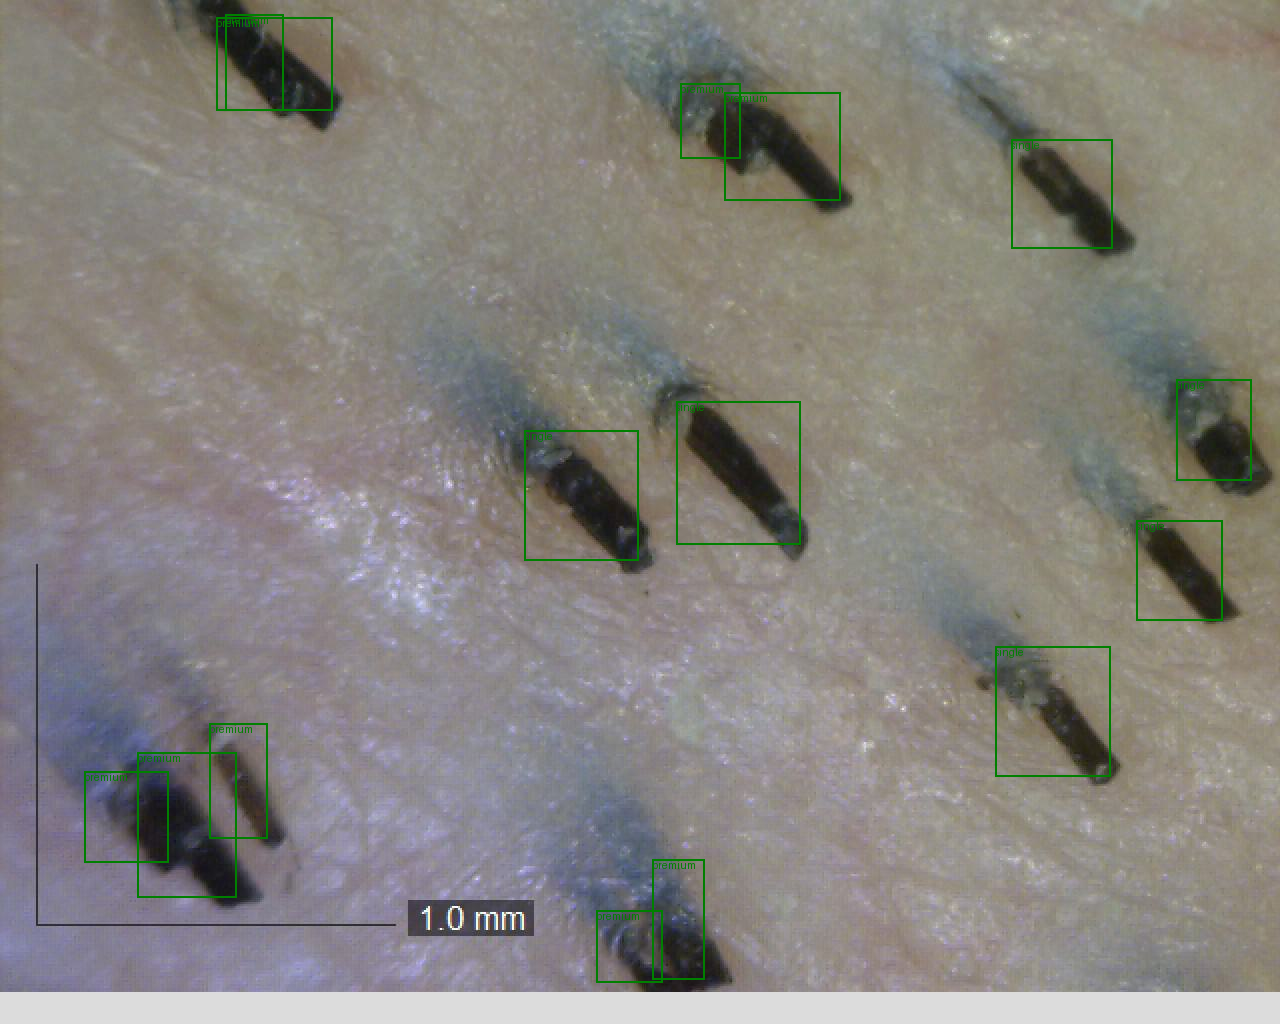

In [33]:
# Run test on single test image
#test
xml_path = os.path.join(cfg.annot_dir, "220105_A095_3.xml")
image_path = os.path.join(cfg.image_dir, "220105_A095_3.jpg")
parsed = parse_voc_xml(xml_path, label2id)

gt_boxes = [obj["bbox_xyxy"] for obj in parsed["objects"]]
gt_labels = [obj["class_id"] for obj in parsed["objects"]]

img = predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=gt_boxes,
    gt_labels=gt_labels,
    threshold=0.5
)

img